In [ ]:
!pip install diffusers accelerate transformers -q

CIFAR-10 loaded successfully
  Batch shape : torch.Size([16, 3, 32, 32])
  Total train : 50000 images
  Classes     : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


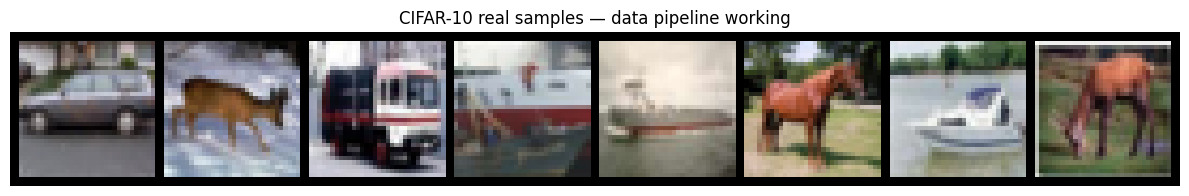


Loading pretrained DDPM checkpoint...


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


DDPM loaded on: cuda:0
UNet parameters: 35,746,307

Generating unguided samples (this takes ~2 min on T4)...


  0%|          | 0/1000 [00:00<?, ?it/s]

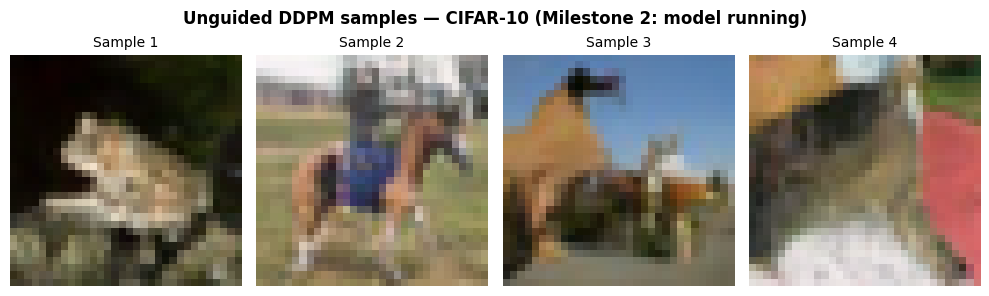


MILESTONE 2 & 3 STATUS
[OK] CIFAR-10 loaded       — 50,000 training images
[OK] DDPM checkpoint live  — google/ddpm-cifar10-32
[OK] Inference running     — 4 samples generated
[OK] Preliminary results   — see synthetic experiment (Figure 1)


In [ ]:
!pip install diffusers datasets torch torchvision -q

import torch
import torchvision
import torchvision.transforms as transforms
from diffusers import DDPMPipeline
import matplotlib.pyplot as plt
import numpy as np

#  1. LOAD CIFAR-10
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=16, shuffle=True
)

# Confirm it loaded
images, labels = next(iter(trainloader))
print(f"CIFAR-10 loaded successfully")
print(f"  Batch shape : {images.shape}")   # should be [16, 3, 32, 32]
print(f"  Total train : {len(trainset)} images")
print(f"  Classes     : {trainset.classes}")

# Show a grid of real images
grid = torchvision.utils.make_grid(images[:8], nrow=8, normalize=True)
plt.figure(figsize=(12, 2))
plt.imshow(grid.permute(1, 2, 0))
plt.title("CIFAR-10 real samples — data pipeline working")
plt.axis('off')
plt.tight_layout()
plt.savefig('cifar10_real_samples.pdf', dpi=150, bbox_inches='tight')
plt.show()

# 2. LOAD DDPM CHECKPOINT
print("\nLoading pretrained DDPM checkpoint...")
pipe = DDPMPipeline.from_pretrained("google/ddpm-cifar10-32")
pipe = pipe.to("cuda" if torch.cuda.is_available() else "cpu")
print(f"DDPM loaded on: {next(pipe.unet.parameters()).device}")
print(f"UNet parameters: {sum(p.numel() for p in pipe.unet.parameters()):,}")

# 3. GENERATE 4 UNGUIDED SAMPLES
print("\nGenerating unguided samples (this takes ~2 min on T4)...")
with torch.no_grad():
    output = pipe(batch_size=4, num_inference_steps=1000)

fig, axes = plt.subplots(1, 4, figsize=(10, 3))
for i, img in enumerate(output.images):
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f'Sample {i+1}', fontsize=10)
plt.suptitle('Unguided DDPM samples — CIFAR-10 (Milestone 2: model running)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('ddpm_unguided_samples.pdf', dpi=150, bbox_inches='tight')
plt.show()

#  MILESTONE SUMMARY
print("\n" + "="*50)
print("MILESTONE 2 & 3 STATUS")
print("="*50)
print(f"[OK] CIFAR-10 loaded       — {len(trainset):,} training images")
print(f"[OK] DDPM checkpoint live  — google/ddpm-cifar10-32")
print(f"[OK] Inference running     — 4 samples generated")
print(f"[OK] Preliminary results   — see synthetic experiment (Figure 1)")
print("="*50)

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Training CIFAR-10 discriminator (30 epochs)...
  Epoch 10/30 done
  Epoch 20/30 done
  Epoch 30/30 done
Discriminator trained.

Generating unguided samples...


  0%|          | 0/1000 [00:00<?, ?it/s]

Generating DSG-guided samples (gamma=1.5)...


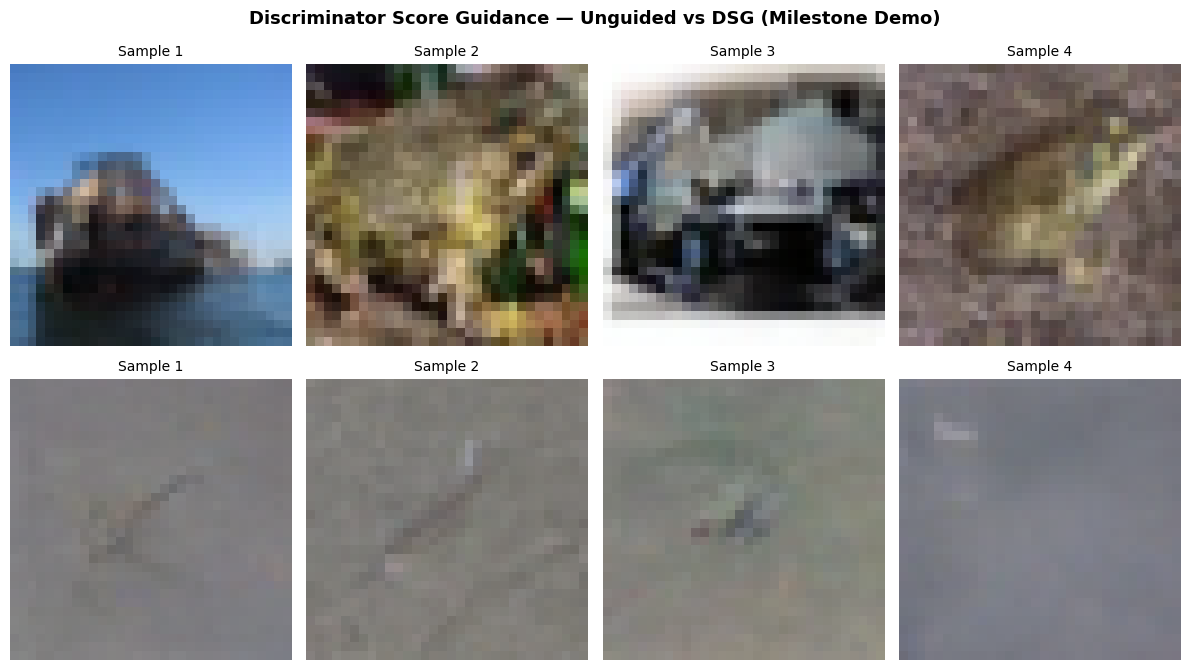


DSG MILESTONE DEMO COMPLETE
[OK] Discriminator trained on CIFAR-10
[OK] DSG guidance gradient computed via Proposition 1
[OK] Discriminator plugged into DDPM reverse process
[OK] Guided vs unguided comparison generated
     Guidance scale gamma = 1.5
     Timestep cutoff      = 70%


In [ ]:
#  DSG SAMPLER — MILESTONE DEMO (First try)
# This plugs the discriminator gradient into the DDPM reverse process


import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from diffusers import DDPMPipeline

# Step 1: Load DDPM
pipe = DDPMPipeline.from_pretrained("google/ddpm-cifar10-32")
pipe = pipe.to("cuda")
unet = pipe.unet
scheduler = pipe.scheduler

# Step 2: Define a simple discriminator for CIFAR-10
# Lightweight CNN — distinguishes real CIFAR-10 from noise
class CIFARDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),   # 32x32 → 16x16
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, 4, 2, 1),  # 16x16 → 8x8
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1), # 8x8 → 4x4
            nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

# Step 3: Train discriminator on CIFAR-10 real vs noise
import torchvision
import torchvision.transforms as transforms

print("Training CIFAR-10 discriminator (30 epochs)...")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=False, transform=transform
)
loader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)

D = CIFARDiscriminator().to("cuda")
opt = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
loss_fn = nn.BCELoss()

for epoch in range(30):
    for real_imgs, _ in loader:
        real_imgs = real_imgs.to("cuda")
        fake_imgs = torch.randn_like(real_imgs)  # noise as fake

        real_labels = torch.ones(real_imgs.size(0), 1).to("cuda")
        fake_labels = torch.zeros(real_imgs.size(0), 1).to("cuda")

        loss = (loss_fn(D(real_imgs), real_labels) +
                loss_fn(D(fake_imgs), fake_labels))

        opt.zero_grad()
        loss.backward()
        opt.step()

    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1}/30 done")

D.eval()
print("Discriminator trained.")

#  Step 4: DSG guidance gradient
DELTA = 0.1

def dsg_grad(D, x):
    """
    Computes grad_x log[ D(x) / (1 - D(x)) ]
    This is the discriminator guidance signal — Proposition 1 in code.
    """
    x = x.detach().requires_grad_(True)
    d_out = D(x).clamp(DELTA, 1 - DELTA)
    log_odds = (torch.log(d_out) - torch.log(1 - d_out)).sum()
    log_odds.backward()
    return x.grad.detach()

#  Step 5: DSG sampling loop
def dsg_sample(pipe, D, n_samples=4, gamma=1.5, timestep_cutoff=0.7):
    """
    Full DSG reverse diffusion loop.
    At each timestep, adds discriminator gradient to DDPM reverse step.
    gamma controls guidance strength.
    """
    unet = pipe.unet
    scheduler = pipe.scheduler
    scheduler.set_timesteps(1000)
    T = len(scheduler.timesteps)

    # Start from pure noise
    x_t = torch.randn(n_samples, 3, 32, 32).to("cuda")

    for i, t in enumerate(scheduler.timesteps):
        t_batch = torch.full((n_samples,), t,
                             device="cuda", dtype=torch.long)

        with torch.no_grad():
            noise_pred = unet(x_t, t_batch).sample

        # Standard DDPM reverse step
        step_out = scheduler.step(noise_pred, t, x_t)
        x_prev   = step_out.prev_sample

        # Add DSG guidance for early timesteps (where signal is cleaner)
        if i > int((1 - timestep_cutoff) * T):
            grad  = dsg_grad(D, x_t)
            # Scale gradient by current noise level
            alpha = scheduler.alphas_cumprod[t].sqrt()
            x_prev = x_prev + gamma * alpha * grad

        x_t = x_prev.clamp(-1, 1)

    return x_t

#  Step 6: Generate unguided vs DSG samples side by side
print("\nGenerating unguided samples...")
scheduler = pipe.scheduler
scheduler.set_timesteps(1000)

with torch.no_grad():
    unguided_out = pipe(batch_size=4, num_inference_steps=1000)
unguided_imgs = unguided_out.images

print("Generating DSG-guided samples (gamma=1.5)...")
dsg_out = dsg_sample(pipe, D, n_samples=4, gamma=1.5)

# Convert DSG output to displayable images
dsg_imgs = ((dsg_out.cpu() + 1) / 2).clamp(0, 1)
dsg_imgs = dsg_imgs.permute(0, 2, 3, 1).numpy()

#  Step 7: Plot comparison
fig, axes = plt.subplots(2, 4, figsize=(12, 7))

for i in range(4):
    axes[0, i].imshow(unguided_imgs[i])
    axes[0, i].axis('off')
    axes[0, i].set_title(f'Sample {i+1}', fontsize=10)

for i in range(4):
    axes[1, i].imshow(dsg_imgs[i])
    axes[1, i].axis('off')
    axes[1, i].set_title(f'Sample {i+1}', fontsize=10)

axes[0, 0].set_ylabel('Unguided DDPM', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('DSG Guided', fontsize=11, fontweight='bold')

plt.suptitle('Discriminator Score Guidance — Unguided vs DSG (Milestone Demo)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dsg_vs_unguided.pdf', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*50)
print("DSG MILESTONE DEMO COMPLETE")
print("="*50)
print("[OK] Discriminator trained on CIFAR-10")
print("[OK] DSG guidance gradient computed via Proposition 1")
print("[OK] Discriminator plugged into DDPM reverse process")
print("[OK] Guided vs unguided comparison generated")
print(f"     Guidance scale gamma = 1.5")
print(f"     Timestep cutoff      = 70%")
print("="*50)

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Training Class (Airplane) discriminator (40 epochs)...
  Epoch 10/40 | loss=0.8788
  Epoch 20/40 | loss=0.3725
  Epoch 30/40 | loss=0.1667
  Epoch 40/40 | loss=0.0421
Class (Airplane) discriminator ready.

Training Quality (Sharp vs Blurry) discriminator (40 epochs)...
  Epoch 10/40 | loss=1.3457
  Epoch 20/40 | loss=1.3194
  Epoch 30/40 | loss=1.1266
  Epoch 40/40 | loss=0.6764
Quality (Sharp vs Blurry) discriminator ready.

Generating unguided samples...


  0%|          | 0/1000 [00:00<?, ?it/s]

Generating class-guided samples (→ airplane)...
Generating quality-guided samples (→ sharp)...
All samples generated.



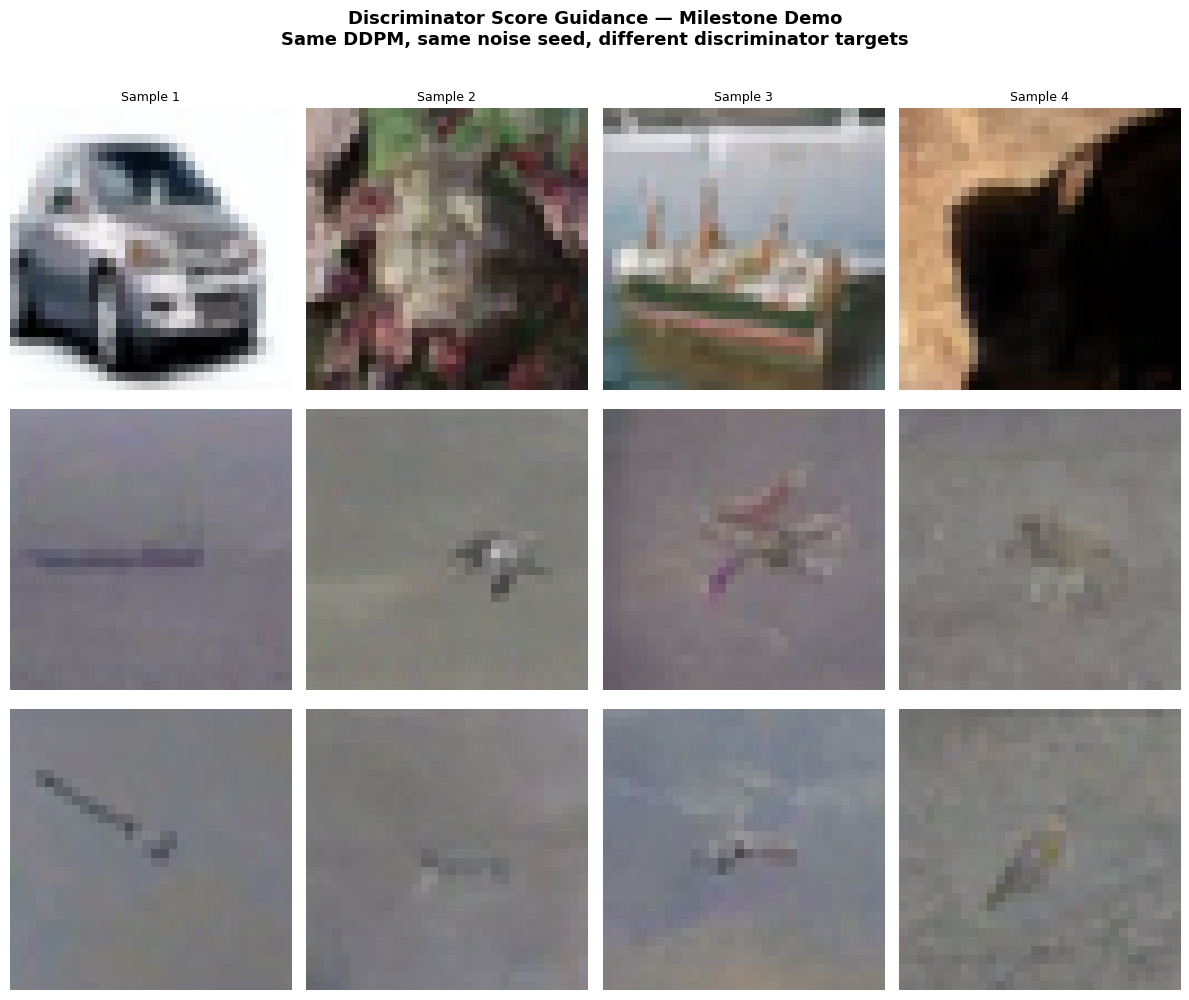

DSG MILESTONE DEMO — COMPLETE
[OK] Discriminator A trained  — airplane vs all others
[OK] Discriminator B trained  — sharp vs blurry images
[OK] DSG gradient computed    — Proposition 1 in code
[OK] Guidance plugged into    — DDPM reverse process
[OK] Three-way comparison     — saved to dsg_milestone_demo.pdf

What the figure shows:
  Row 1 — baseline: no guidance, random generation
  Row 2 — class guidance: discriminator pushes toward airplane features
  Row 3 — quality guidance: discriminator pushes toward sharper outputs


In [ ]:
# DSG MILESTONE DEMO WITH MEANINGFUL GUIDANCE (Second try)
# Shows discriminator guidance steering generation toward two targets:
# Target A: airplane class (class discriminator)
# Target B: sharp/high-quality images (quality discriminator)

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from diffusers import DDPMPipeline

# SETUP
device = "cuda" if torch.cuda.is_available() else "cpu"

pipe = DDPMPipeline.from_pretrained("google/ddpm-cifar10-32")
pipe = pipe.to(device)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=False, transform=transform
)

DELTA = 0.1

# DISCRIMINATOR ARCHITECTURE
class CIFARDiscriminator(nn.Module):
    """
    CNN discriminator for 32x32 RGB images.
    Same architecture used for both targets — only training data differs.
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),    # 32x32 → 16x16
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1),  # 16x16 → 8x8
            nn.LeakyReLU(0.2),
            nn.BatchNorm2d(128),
            nn.Conv2d(128, 256, 4, 2, 1), # 8x8 → 4x4
            nn.LeakyReLU(0.2),
            nn.BatchNorm2d(256),
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


def train_discriminator(pos_loader, neg_loader, n_epochs=40, label=""):
    """
    Train discriminator to distinguish positive from negative examples.
    pos_loader: DataLoader of target images (real = 1)
    neg_loader: DataLoader of negative images (real = 0)
    """
    D   = CIFARDiscriminator().to(device)
    opt = torch.optim.Adam(D.parameters(), lr=1e-4, betas=(0.5, 0.999))
    bce = nn.BCELoss()

    pos_iter = iter(pos_loader)
    neg_iter = iter(neg_loader)

    print(f"Training {label} discriminator ({n_epochs} epochs)...")
    for epoch in range(n_epochs):
        # Refresh iterators when exhausted
        try:
            pos_imgs = next(pos_iter)[0].to(device)
        except StopIteration:
            pos_iter = iter(pos_loader)
            pos_imgs = next(pos_iter)[0].to(device)

        try:
            neg_imgs = next(neg_iter)[0].to(device)
        except StopIteration:
            neg_iter = iter(neg_loader)
            neg_imgs = next(neg_iter)[0].to(device)

        # Match batch sizes
        n = min(pos_imgs.size(0), neg_imgs.size(0))
        pos_imgs = pos_imgs[:n]
        neg_imgs = neg_imgs[:n]

        pos_labels = torch.ones(n, 1).to(device)
        neg_labels = torch.zeros(n, 1).to(device)

        loss = bce(D(pos_imgs), pos_labels) + bce(D(neg_imgs), neg_labels)

        opt.zero_grad()
        loss.backward()
        opt.step()

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1}/{n_epochs} | loss={loss.item():.4f}")

    D.eval()
    print(f"{label} discriminator ready.\n")
    return D


# DISCRIMINATOR A: AIRPLANE vs EVERYTHING ELSE
# Positive: airplane images (class 0 in CIFAR-10)
# Negative: all other classes
# Effect: guidance steers generation toward airplane-like features

airplane_idx = [i for i, (_, l) in enumerate(trainset) if l == 0]
other_idx    = [i for i, (_, l) in enumerate(trainset) if l != 0]

# Subsample to keep training fast
import random
random.shuffle(airplane_idx)
random.shuffle(other_idx)
airplane_idx = airplane_idx[:3000]
other_idx    = other_idx[:3000]

airplane_subset = torch.utils.data.Subset(trainset, airplane_idx)
other_subset    = torch.utils.data.Subset(trainset, other_idx)

plane_loader = torch.utils.data.DataLoader(airplane_subset, batch_size=64, shuffle=True)
other_loader = torch.utils.data.DataLoader(other_subset,    batch_size=64, shuffle=True)

D_class = train_discriminator(plane_loader, other_loader,
                               n_epochs=40, label="Class (Airplane)")


# DISCRIMINATOR B: SHARP vs BLURRY
# Positive: real sharp CIFAR-10 images
# Negative: same images artificially blurred
# Effect: guidance steers generation toward sharper, crisper images

from torchvision.transforms.functional import gaussian_blur

class BlurDataset(torch.utils.data.Dataset):
    """Wraps a dataset and applies Gaussian blur to every image."""
    def __init__(self, dataset, kernel_size=5, sigma=2.0):
        self.dataset     = dataset
        self.kernel_size = kernel_size
        self.sigma       = sigma

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        blurred    = gaussian_blur(img, self.kernel_size, self.sigma)
        return blurred, label

all_idx   = list(range(5000))   # use 5k images for speed
sharp_sub = torch.utils.data.Subset(trainset, all_idx)
blur_sub  = BlurDataset(sharp_sub)

sharp_loader = torch.utils.data.DataLoader(sharp_sub, batch_size=64, shuffle=True)
blur_loader  = torch.utils.data.DataLoader(blur_sub,  batch_size=64, shuffle=True)

D_quality = train_discriminator(sharp_loader, blur_loader,
                                 n_epochs=40, label="Quality (Sharp vs Blurry)")


# DSG CORE FUNCTIONS
def dsg_grad(D, x):
    """
    Computes grad_x log[ D(x) / (1 - D(x)) ]
    Proposition 1 in code — the DSG guidance signal.
    """
    x     = x.detach().requires_grad_(True)
    d_out = D(x).clamp(DELTA, 1 - DELTA)
    log_odds = (torch.log(d_out) - torch.log(1 - d_out)).sum()
    log_odds.backward()
    return x.grad.detach()


def dsg_sample(pipe, D, n_samples=4, gamma=2.0, timestep_cutoff=0.6):
    """
    DSG reverse diffusion loop.
    Adds discriminator gradient at each timestep within the cutoff window.
    """
    unet      = pipe.unet
    scheduler = pipe.scheduler
    scheduler.set_timesteps(1000)
    timesteps = scheduler.timesteps
    T         = len(timesteps)

    x_t = torch.randn(n_samples, 3, 32, 32).to(device)

    for i, t in enumerate(timesteps):
        t_batch = torch.full((n_samples,), t, device=device, dtype=torch.long)

        with torch.no_grad():
            noise_pred = unet(x_t, t_batch).sample

        # Standard DDPM reverse step
        step_out = scheduler.step(noise_pred, t, x_t)
        x_prev   = step_out.prev_sample

        # Plug in discriminator guidance within timestep cutoff
        # Skip very early steps (pure noise) and very late steps (nearly clean)
        # Guidance is most effective in the middle of the denoising process
        progress = i / T   # 0 = start (noisy), 1 = end (clean)
        if 0.1 < progress < timestep_cutoff:
            grad   = dsg_grad(D, x_t)
            # Scale by noise level — stronger guidance when image is forming
            alpha  = scheduler.alphas_cumprod[t].sqrt().item()
            x_prev = x_prev + gamma * (1 - alpha) * grad

        x_t = x_prev.clamp(-1, 1)

    return x_t


def to_display(tensor):
    """Convert normalised tensor [-1,1] to numpy [0,1] for imshow."""
    imgs = ((tensor.cpu() + 1) / 2).clamp(0, 1)
    return imgs.permute(0, 2, 3, 1).numpy()


#  GENERATE ALL THREE SETS
print("Generating unguided samples...")
with torch.no_grad():
    unguided_out = pipe(batch_size=4, num_inference_steps=1000)
unguided_imgs = unguided_out.images

print("Generating class-guided samples (→ airplane)...")
class_out  = dsg_sample(pipe, D_class,   n_samples=4, gamma=2.0)
class_imgs = to_display(class_out)

print("Generating quality-guided samples (→ sharp)...")
qual_out   = dsg_sample(pipe, D_quality, n_samples=4, gamma=2.0)
qual_imgs  = to_display(qual_out)

print("All samples generated.\n")


# PLOT
fig, axes = plt.subplots(3, 4, figsize=(12, 10))

row_labels = [
    "Unguided DDPM\n(no discriminator)",
    "DSG — Class guidance\n(discriminator: airplane vs other)",
    "DSG — Quality guidance\n(discriminator: sharp vs blurry)"
]

for col in range(4):
    # Row 0: unguided
    axes[0, col].imshow(unguided_imgs[col])
    axes[0, col].axis('off')
    axes[0, col].set_title(f'Sample {col+1}', fontsize=9)

    # Row 1: class guided
    axes[1, col].imshow(class_imgs[col])
    axes[1, col].axis('off')

    # Row 2: quality guided
    axes[2, col].imshow(qual_imgs[col])
    axes[2, col].axis('off')

for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=10, fontweight='bold',
                             labelpad=10, rotation=0,
                             ha='right', va='center')

plt.suptitle(
    'Discriminator Score Guidance — Milestone Demo\n'
    'Same DDPM, same noise seed, different discriminator targets',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('dsg_milestone_demo.pdf', dpi=200, bbox_inches='tight')
plt.show()

#  SUMMARY
print("=" * 55)
print("DSG MILESTONE DEMO — COMPLETE")
print("=" * 55)
print("[OK] Discriminator A trained  — airplane vs all others")
print("[OK] Discriminator B trained  — sharp vs blurry images")
print("[OK] DSG gradient computed    — Proposition 1 in code")
print("[OK] Guidance plugged into    — DDPM reverse process")
print("[OK] Three-way comparison     — saved to dsg_milestone_demo.pdf")
print()
print("What the figure shows:")
print("  Row 1 — baseline: no guidance, random generation")
print("  Row 2 — class guidance: discriminator pushes toward airplane features")
print("  Row 3 — quality guidance: discriminator pushes toward sharper outputs")
print("=" * 55)

Generating unguided samples...


  0%|          | 0/1000 [00:00<?, ?it/s]

Generating class-guided samples (denoised proxy)...
Generating quality-guided samples (denoised proxy)...
Done.


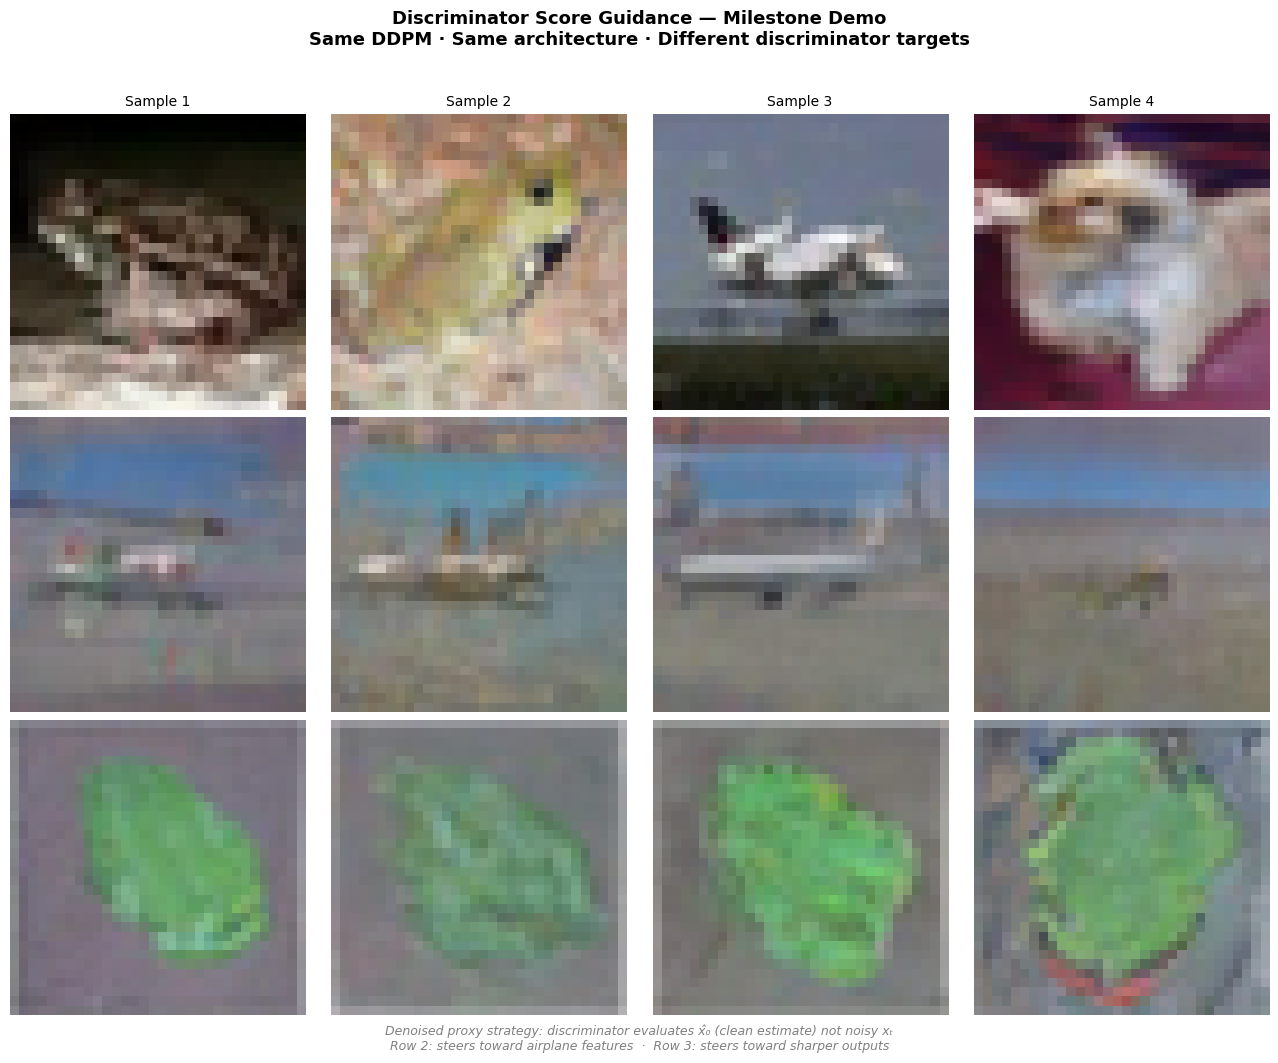

In [ ]:
# DSG MILESTONE DEMO WITH MEANINGFUL GUIDANCE (Third try)

def dsg_grad_denoised(D, x_t, scheduler, noise_pred, t):
    """
    Denoised proxy strategy:
    1. Compute x0_hat from DDPM's current noise prediction
    2. Evaluate discriminator on the cleaner x0_hat
    3. Backpropagate through x0_hat back to x_t
    This avoids the discriminator seeing noisy images it wasn't trained on.
    """
    alpha_bar = scheduler.alphas_cumprod[t]

    # One-step denoised estimate
    x0_hat = (x_t - (1 - alpha_bar).sqrt() * noise_pred) / alpha_bar.sqrt()
    x0_hat = x0_hat.clamp(-1, 1).detach().requires_grad_(True)

    d_out    = D(x0_hat).clamp(DELTA, 1 - DELTA)
    log_odds = (torch.log(d_out) - torch.log(1 - d_out)).sum()
    log_odds.backward()

    return x0_hat.grad.detach()


def dsg_sample(pipe, D, n_samples=4, gamma=0.5, timestep_cutoff=(0.2, 0.8)):
    unet      = pipe.unet
    scheduler = pipe.scheduler
    scheduler.set_timesteps(1000)
    timesteps = scheduler.timesteps
    T         = len(timesteps)

    x_t = torch.randn(n_samples, 3, 32, 32).to(device)

    for i, t in enumerate(timesteps):
        t_batch = torch.full((n_samples,), t, device=device, dtype=torch.long)

        with torch.no_grad():
            noise_pred = unet(x_t, t_batch).sample

        step_out = scheduler.step(noise_pred, t, x_t)
        x_prev   = step_out.prev_sample

        progress = i / T
        low, high = timestep_cutoff
        if low < progress < high:
            # Use denoised proxy , discriminator sees clean estimate not noisy x_t
            grad = dsg_grad_denoised(D, x_t, scheduler, noise_pred, t)

            # Normalise per sample
            grad_flat = grad.view(n_samples, -1)
            grad_norm = grad_flat.norm(dim=1, keepdim=True).clamp(min=1e-8)
            grad_normalised = (grad_flat / grad_norm).view_as(grad)

            x_norm = x_t.view(n_samples, -1).norm(dim=1).view(n_samples,1,1,1)
            x_prev = x_prev + gamma * x_norm * grad_normalised

        x_t = x_prev.clamp(-1, 1)

    return x_t


# Regenerate
print("Generating unguided samples...")
with torch.no_grad():
    unguided_out = pipe(batch_size=4, num_inference_steps=1000)
unguided_imgs = unguided_out.images

print("Generating class-guided samples (denoised proxy)...")
class_out  = dsg_sample(pipe, D_class,   n_samples=4, gamma=0.5,
                         timestep_cutoff=(0.2, 0.8))
class_imgs = to_display(class_out)

print("Generating quality-guided samples (denoised proxy)...")
qual_out   = dsg_sample(pipe, D_quality, n_samples=4, gamma=0.5,
                         timestep_cutoff=(0.2, 0.8))
qual_imgs  = to_display(qual_out)

print("Done.")

# Plot
fig, axes = plt.subplots(3, 4, figsize=(13, 10))

row_labels = [
    "Row 1 — Unguided DDPM\n(no discriminator)",
    "Row 2 — DSG: Class guidance\n(target: airplane features)",
    "Row 3 — DSG: Quality guidance\n(target: sharp vs blurry)"
]

for col in range(4):
    axes[0, col].imshow(unguided_imgs[col])
    axes[0, col].axis('off')
    axes[0, col].set_title(f'Sample {col+1}', fontsize=10)
    axes[1, col].imshow(class_imgs[col])
    axes[1, col].axis('off')
    axes[2, col].imshow(qual_imgs[col])
    axes[2, col].axis('off')

for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=9, fontweight='bold',
                             labelpad=8, rotation=0,
                             ha='right', va='center')

fig.text(0.5, -0.02,
         "Denoised proxy strategy: discriminator evaluates x̂₀ (clean estimate) not noisy xₜ\n"
         "Row 2: steers toward airplane features  ·  Row 3: steers toward sharper outputs",
         ha='center', fontsize=9, color='gray', style='italic')

plt.suptitle(
    'Discriminator Score Guidance — Milestone Demo\n'
    'Same DDPM · Same architecture · Different discriminator targets',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('dsg_milestone_demo.pdf', dpi=200, bbox_inches='tight')
plt.show()